In [1]:
!pip install pandas matplotlib seaborn scikit-learn

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


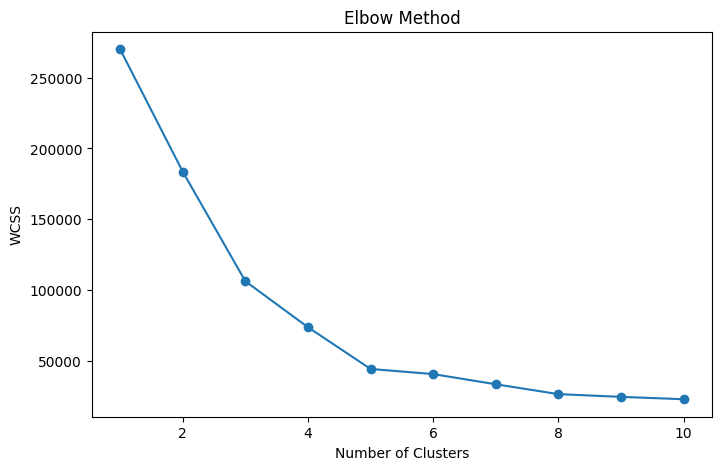

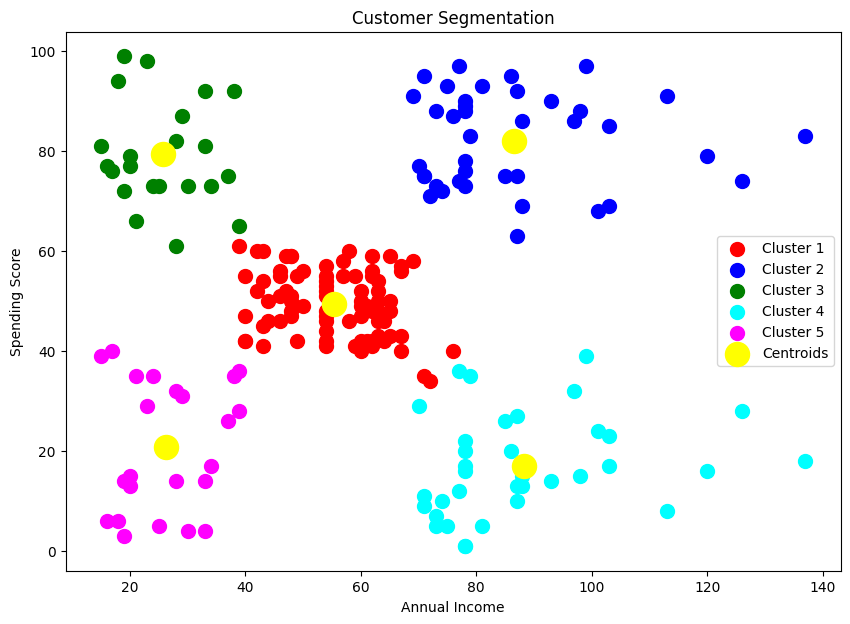

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  

Cluster Summary:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         86.320988  0.407407  42.716049           55.296296   
1        162.000000  0.461538  32.692308           86.538462   
2         23.090909  0.409091  25.272727           25.727273   
3        164.371429  0.542857  41.114286           88.200000   
4         23.000000  0.391304  45.217391           26.304348   

         S

In [4]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
print(df.head())

# Check dataset info
print(df.info())

# Convert Gender into numeric values
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])

# Select important columns
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Find optimal clusters using Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)

# Predict clusters
y_kmeans = kmeans.fit_predict(X)

# Add clusters to dataset
df['Cluster'] = y_kmeans

# Visualize clusters
plt.figure(figsize=(10,7))

plt.scatter(X.iloc[y_kmeans == 0, 0], X.iloc[y_kmeans == 0, 1],
            s=100, c='red', label='Cluster 1')

plt.scatter(X.iloc[y_kmeans == 1, 0], X.iloc[y_kmeans == 1, 1],
            s=100, c='blue', label='Cluster 2')

plt.scatter(X.iloc[y_kmeans == 2, 0], X.iloc[y_kmeans == 2, 1],
            s=100, c='green', label='Cluster 3')

plt.scatter(X.iloc[y_kmeans == 3, 0], X.iloc[y_kmeans == 3, 1],
            s=100, c='cyan', label='Cluster 4')

plt.scatter(X.iloc[y_kmeans == 4, 0], X.iloc[y_kmeans == 4, 1],
            s=100, c='magenta', label='Cluster 5')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=300,
            c='yellow',
            label='Centroids')

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

# Display clustered data
print(df.head())

# Cluster analysis
cluster_summary = df.groupby('Cluster').mean()

print("\nCluster Summary:")
print(cluster_summary)